# SPT-3G BB Analysis — Initial Exploration

Local development notebook for SPT-3G CMB polarization analysis.  
Real data lives on the cluster; the hardcoded paths in §1 are cluster-only.

In [9]:
import os, sys
import numpy as np
import healpy as hp
import matplotlib
import matplotlib.pyplot as plt
from spt3g import core,maps

from Plot import (
    apply_spt_style,
    mask_map,
    show_map_full_field,
    show_map_thumbnail,
    show_1d_functions_of_ell,
    show_alm_triangle,
    MapPlotter,
)

# Apply SPT-3G standard plot style for the whole notebook
apply_spt_style()

print("python     :", sys.version)
print("numpy      :", np.__version__)
print("healpy     :", hp.__version__)
print("matplotlib :", matplotlib.__version__)

python     : 3.10.1 (main, Jun  4 2024, 03:41:14) [GCC 12.3.0]
numpy      : 1.22.1
healpy     : 1.15.0
matplotlib : 3.5.1


## 1. Data Discovery

> **Cluster only.** These cells explore the raw data directories and will not run locally.

In [10]:
base_sptgrid = "/sptgrid/data/"
for name in sorted(os.listdir(base_sptgrid)):
    path = os.path.join(base_sptgrid, name)
    try:
        children = sorted(os.listdir(path))
        print(f"[{name}]  ({len(children)} items)")
        for c in children[:5]:
            print(f"  {c}")
    except (NotADirectoryError, PermissionError) as e:
        print(f"[{name}]  ({type(e).__name__})")

[3g_verified]  (0 items)


[arc]  (589040 items)
  .20180303_165838.dat.J6myqQ
  .20180304_161838.dat.7eLzLi
  .20180305_071838.dat.zFMQ8Q
  .20180305_120158.dat.qGCfJV
  .20180305_150518.dat.Fs0FK7
[balloon_gps_data]  (5 items)
  2017
  2018
  2019
  2020
  2021
[bolodata]  (2 items)
  downsampled
  fullrate
[onlinemaps]  (63 items)
  J1745-290
  calframe
  calibration
  lightcurve
  monthly_coadds
[sptpol]  (34 items)
  (none)
  0521-365
  0537-441
  2255-282
  CenA


> **File structure:** Under `bb2019/full_2019_and_2020/` each subfield has a `pol_sub_optimized_healpix/` directory. Inside, each OBSID has its own sub-directory containing a single `.g3` file named with that OBSID.

In [11]:
base_bb2019 = "/sptlocal/analysis/bb2019/full_2019_and_2020"
print("Subfields:", sorted(os.listdir(base_bb2019)))

Subfields: ['ra0hdec-44.75', 'ra0hdec-52.25', 'ra0hdec-59.75', 'ra0hdec-67.25']


In [12]:
subfield = "ra0hdec-44.75"
obsid    = "118022023"

map_file = (
    f"{base_bb2019}/{subfield}/pol_sub_optimized_healpix/"
    f"{obsid}/pol_sub_optimized_healpix_{obsid}.g3"
)
print(map_file)
print("Exists:", os.path.exists(map_file))

/sptlocal/analysis/bb2019/full_2019_and_2020/ra0hdec-44.75/pol_sub_optimized_healpix/118022023/pol_sub_optimized_healpix_118022023.g3
Exists: True


## 2. Map Inspection

In [13]:
for i, fr in enumerate(core.G3File(map_file)):
    if fr.type == core.G3FrameType.Map:
        print("Map frame index:", i)
        print("Id:", fr["Id"])
        print("Keys:", list(fr.keys()))
        for k in fr.keys():
            print(" ", k, type(fr[k]))
        break

Map frame index: 6
Id: Left90GHz
Keys: ['Q', 'U', 'Id', 'T', 'Wpol']
  Q <class 'spt3g.maps.HealpixSkyMap'>
  U <class 'spt3g.maps.HealpixSkyMap'>
  Id <class 'str'>
  T <class 'spt3g.maps.HealpixSkyMap'>
  Wpol <class 'spt3g.maps.G3SkyMapWeights'>


In [14]:
for fr in core.G3File(map_file):
    if fr.type == core.G3FrameType.Map:
        print("Map Id:", fr["Id"])
        for key in ["T", "Q", "U"]:
            arr  = np.asarray(fr[key])
            good = np.isfinite(arr)
            print(f"\n--- {key} ---")
            print("  nside  :", fr[key].nside)
            print("  units  :", fr[key].units)
            print("  finite :", good.sum())
            print("  min/max/mean:", arr[good].min(),
                                    arr[good].max(),
                                    arr[good].mean())
        break

Map Id: Left90GHz

--- T ---
  nside  : 2048
  units  : Tcmb
  finite : 50331648
  min/max/mean: -12058798591.083391 75350763352.9389 74646.06820164238

--- Q ---
  nside  : 2048
  units  : Tcmb
  finite : 50331648
  min/max/mean: -2990009920.075752 3028386617.1435046 -3180.1537935418723

--- U ---
  nside  : 2048
  units  : Tcmb
  finite : 50331648
  min/max/mean: -2964661609.614376 3106291755.968077 -1206.8947176943454


In [15]:
# Weight map (Wpol) components
for fr in core.G3File(map_file):
    if fr.type == core.G3FrameType.Map:
        w = fr["Wpol"]
        for comp in ["TT", "TQ", "TU", "QQ", "QU", "UU"]:
            print(comp, type(getattr(w, comp)))
        break

TT <class 'spt3g.maps.HealpixSkyMap'>
TQ <class 'spt3g.maps.HealpixSkyMap'>
TU <class 'spt3g.maps.HealpixSkyMap'>
QQ <class 'spt3g.maps.HealpixSkyMap'>
QU <class 'spt3g.maps.HealpixSkyMap'>
UU <class 'spt3g.maps.HealpixSkyMap'>


In [16]:
# All Map frames contained in the .g3 file
for i, fr in enumerate(core.G3File(map_file)):
    if fr.type == core.G3FrameType.Map:
        print(i, fr["Id"])

6 Left90GHz
7 Left150GHz
8 Left220GHz
9 Right90GHz
10 Right150GHz
11 Right220GHz


## 3. Load Map Data

Load all six frequency/side frames into a `frames` dict that `MapPlotter` reads directly. Also define the subfield centre and the 3 × 2 display layout.

In [17]:
target_ids = [
    "Left90GHz",  "Right90GHz",
    "Left150GHz", "Right150GHz",
    "Left220GHz", "Right220GHz",
]

frames = {}
for fr in core.G3File(map_file):
    if fr.type != core.G3FrameType.Map:
        continue
    mid = fr["Id"]
    if mid in target_ids:
        W = fr["Wpol"]
        frames[mid] = {
            "T":  np.asarray(fr["T"],  float),
            "Q":  np.asarray(fr["Q"],  float),
            "U":  np.asarray(fr["U"],  float),
            "TT": np.asarray(W.TT, float),
            "QQ": np.asarray(W.QQ, float),
            "UU": np.asarray(W.UU, float),
        }

print(f"Loaded {len(frames)} frames:", list(frames))

Loaded 6 frames: ['Left90GHz', 'Left150GHz', 'Left220GHz', 'Right90GHz', 'Right150GHz', 'Right220GHz']


In [21]:
# Subfield centre [RA, Dec] degrees — change for each subfield
rot_centre = [0, -44.75]

# 3x2 display layout: rows = frequency, columns = detector side
layout = [
    ("Left90GHz",  "Right90GHz"),
    ("Left150GHz", "Right150GHz"),
    ("Left220GHz", "Right220GHz"),
]

In [22]:
# Pull arrays from one frame for single-map plots and E/B analysis
ref_id = "Left90GHz"
T  = frames[ref_id]["T"]
Q  = frames[ref_id]["Q"]
U  = frames[ref_id]["U"]
TT = frames[ref_id]["TT"]
QQ = frames[ref_id]["QQ"]
UU = frames[ref_id]["UU"]

## 4. Visualisation

All plotting uses `MapPlotter` from `Plot.py`. Two backends: `gnomview` (healpy) and `imshow` (matplotlib via `GnomonicProj`).

In [23]:
# Weight map key helper (used in §4 cells)
_wt = {"T": "TT", "Q": "QQ", "U": "UU"}.get

plotter = MapPlotter(frames)   # kept for multi-panel grid plots

### 4.1 Single-map preview — gnomview

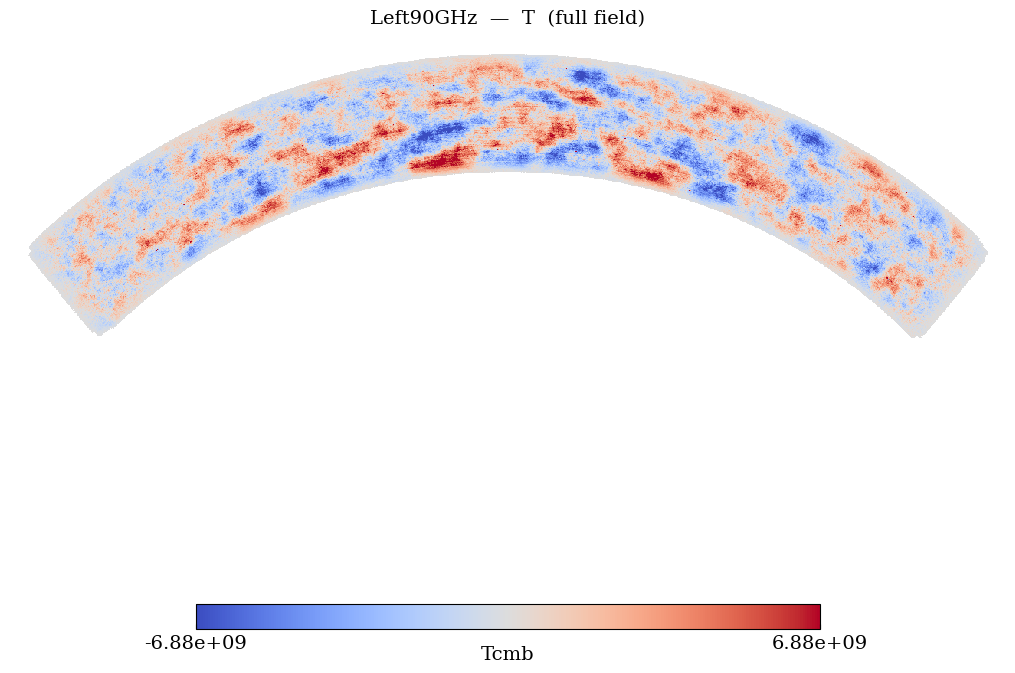

In [24]:
# Full field — all 4 subfields visible at once
# Change map_key to "Q" or "U" to see polarisation maps
map_key = "T"
m   = mask_map(frames[ref_id][map_key], frames[ref_id][_wt(map_key)])
rms = float(np.std(m[m != hp.UNSEEN]))

show_map_full_field(
    m, vmin=-3*rms, vmax=3*rms,
    title=f"{ref_id}  —  {map_key}  (full field)",
    unit="Tcmb", cmap="coolwarm")

### 4.2 Single-map — matplotlib backend

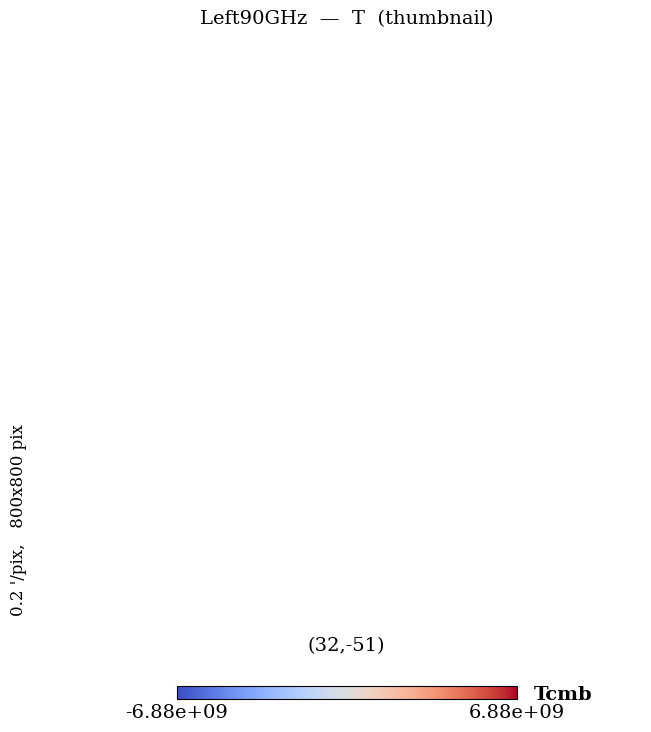

In [25]:
# Zoomed thumbnail — change rot to centre on a different patch
# Default: rot=(32, -51, 0) centres on ra0hdec-52.25 subfield
map_key = "T"
m   = mask_map(frames[ref_id][map_key], frames[ref_id][_wt(map_key)])
rms = float(np.std(m[m != hp.UNSEEN]))

show_map_thumbnail(
    m, vmin=-3*rms, vmax=3*rms,
    title=f"{ref_id}  —  {map_key}  (thumbnail)",
    unit="Tcmb", cmap="coolwarm")

### 4.3 Multi-frequency grids

3 × 2 layout: rows = 90 / 150 / 220 GHz, columns = Left / Right detector set.

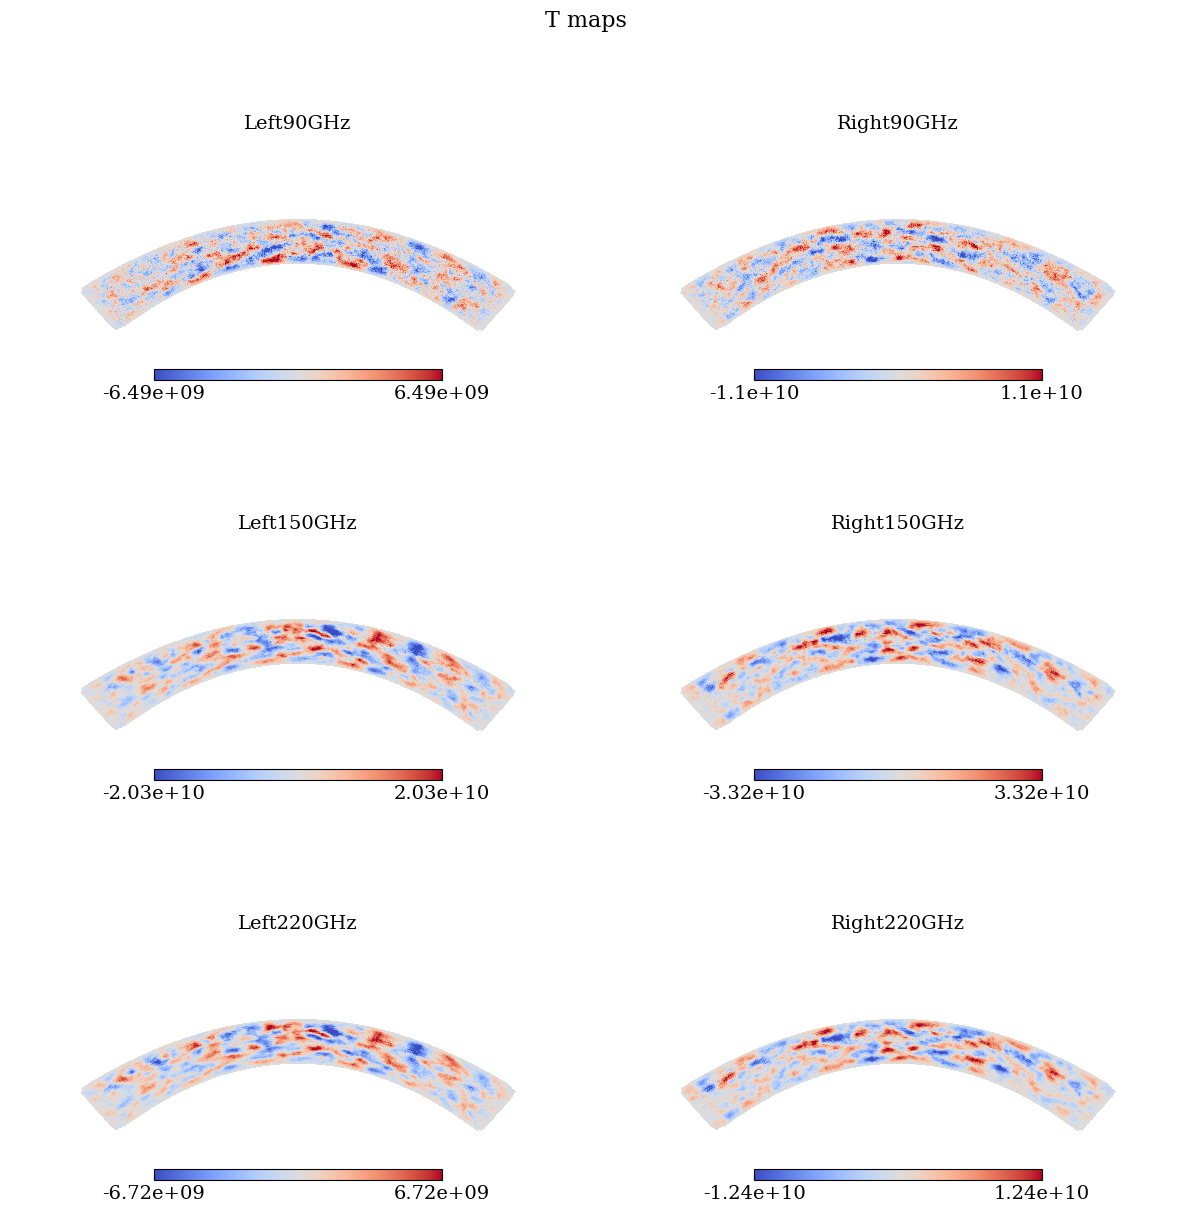

In [26]:
plotter.plot_grid(map_key="T", layout=layout, rot=rot_centre, suptitle="T maps")
plt.show()

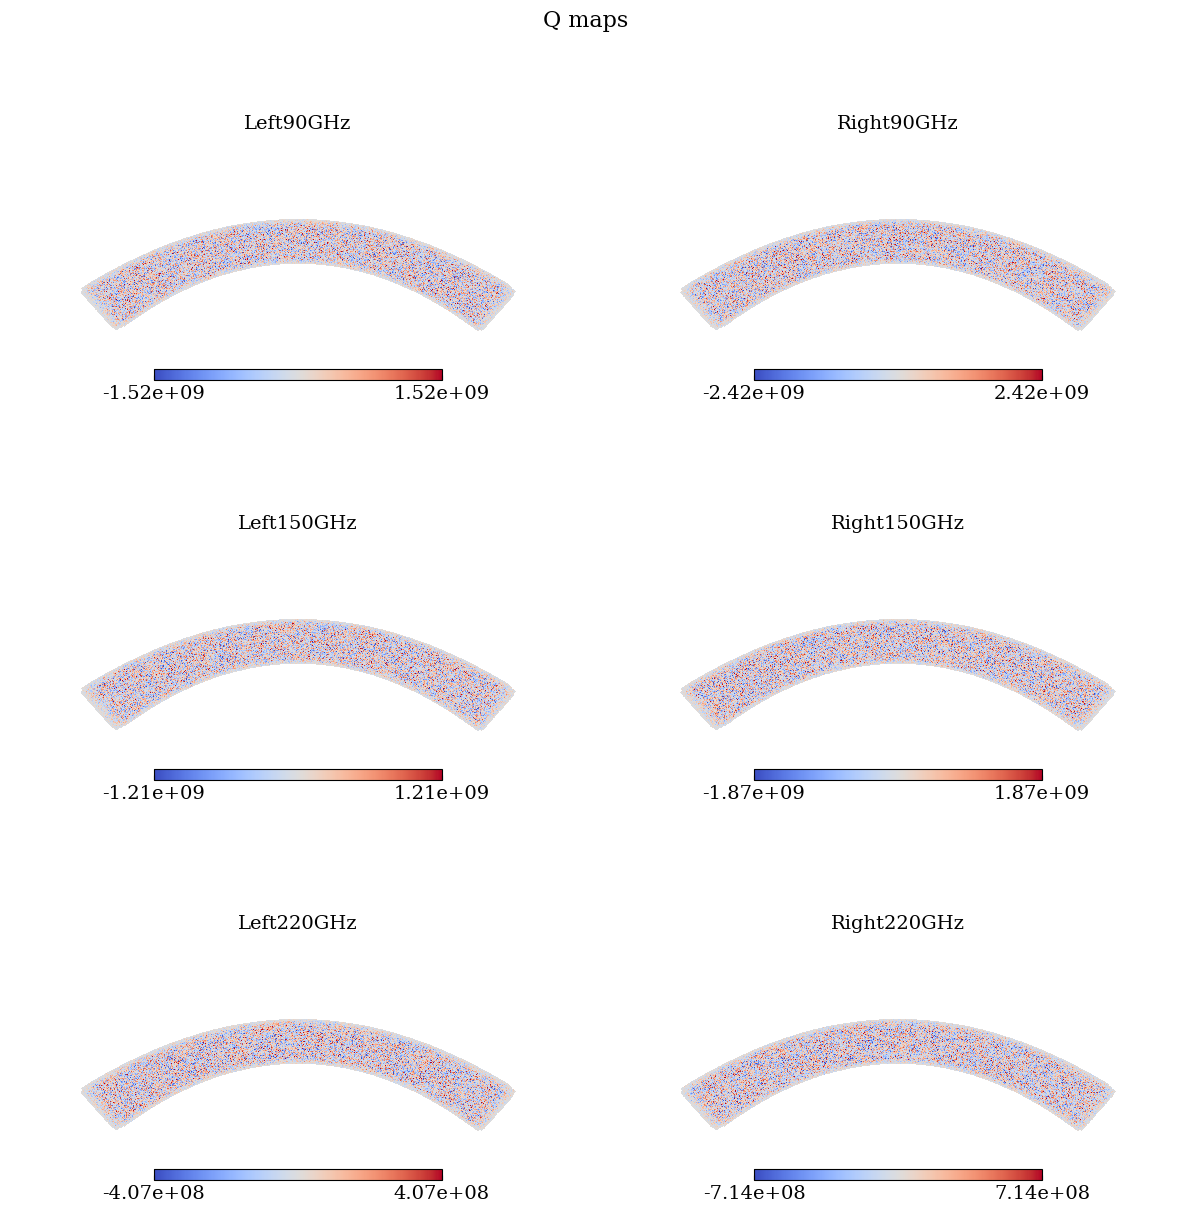

In [27]:
plotter.plot_grid(map_key="Q", layout=layout, rot=rot_centre, suptitle="Q maps")
plt.show()

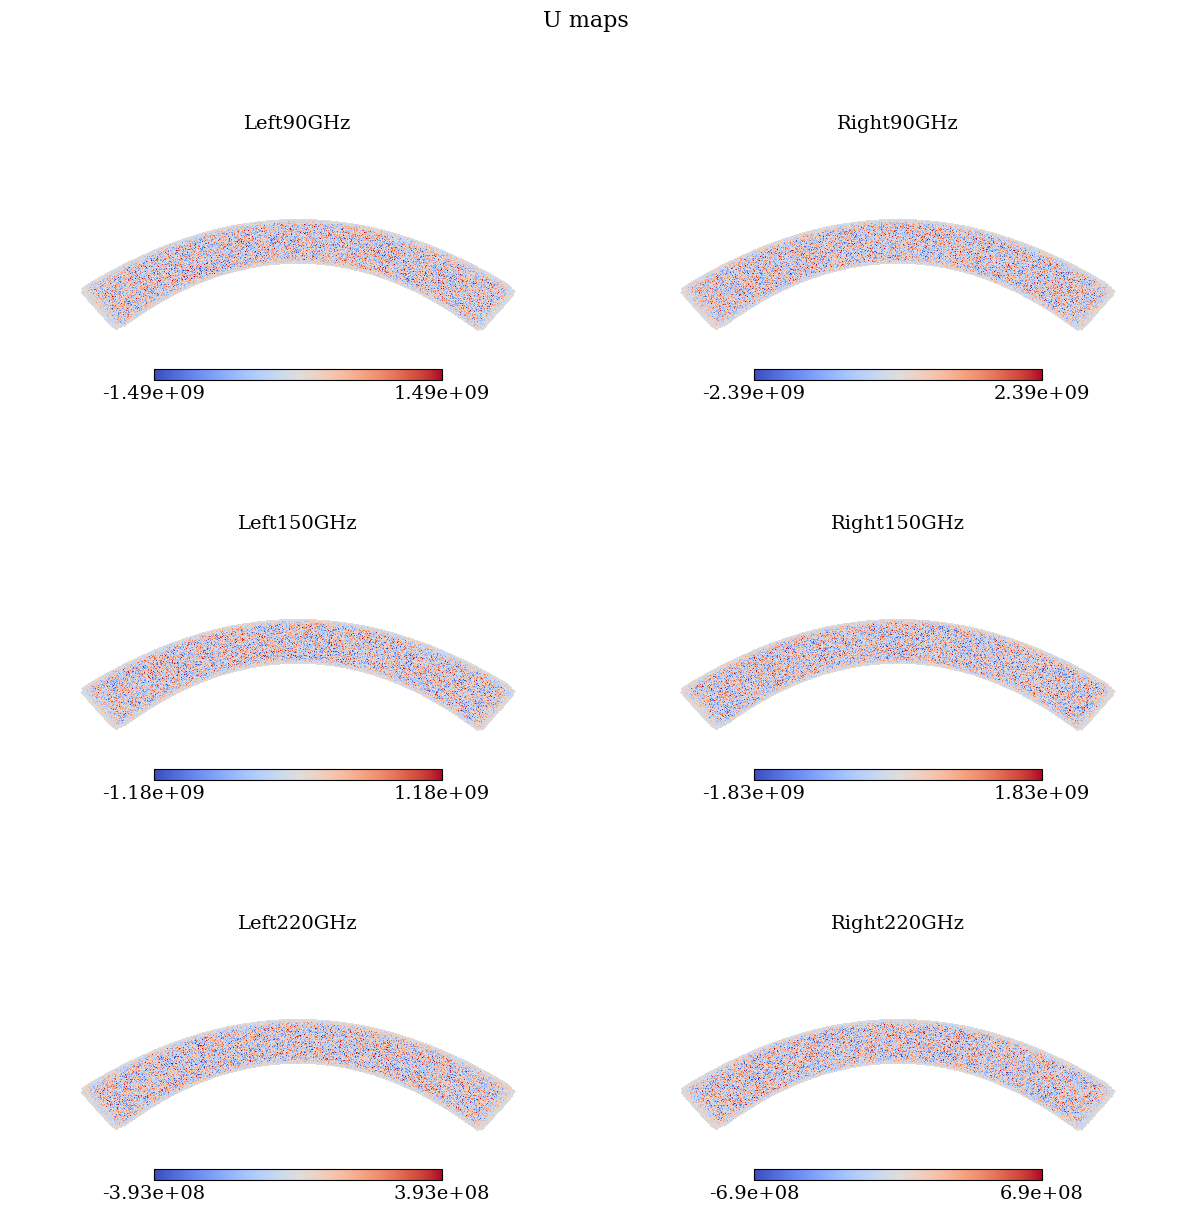

In [28]:
plotter.plot_grid(map_key="U", layout=layout, rot=rot_centre, suptitle="U maps")
plt.show()

## 5. E/B Decomposition

Diagnostic E and B maps from T/Q/U via `healpy.map2alm_lsq`.  
This is a quick inspection tool — not the final pure-B SPT pipeline.

> **Before running:** define `apod_mask` (load from file on the cluster).

In [29]:
def apply_pol_mask(Q, U, obs_mask, apod_mask):
    """
    Apply observed mask + apodisation mask to Q/U.

    For harmonic transforms:
    - observed pixels get Q * apod_mask, U * apod_mask
    - unobserved pixels are set to 0
    """

    Q_clean = np.asarray(Q).copy()
    U_clean = np.asarray(U).copy()

    apod_mask = np.asarray(apod_mask)

    usable = obs_mask.copy()
    usable &= np.isfinite(apod_mask)
    usable &= apod_mask > 0

    Q_clean[usable] *= apod_mask[usable]
    U_clean[usable] *= apod_mask[usable]

    Q_clean[~usable] = 0.0
    U_clean[~usable] = 0.0

    return Q_clean, U_clean, usable

In [ ]:
# obs_pol   = TT > 0                           # simple observed-pixel mask
# apod_mask = np.load("/path/to/apod_mask.npy") # load on cluster

Q_apod, U_apod, usable_pol = apply_pol_mask(Q, U, obs_pol, apod_mask)
print("Usable pixels after apodisation:", usable_pol.sum())

In [ ]:
def make_EB_maps_lsq(
    T,
    Q,
    U,
    TT=None,
    QQ=None,
    UU=None,
    apod_mask=None,
    lmax=512,
    mmax=None,
    tol=1e-8,
    maxiter=20,
):
    """
    Make quick diagnostic E/B maps from T/Q/U using healpy.sphtfunc.map2alm_lsq.

    WARNING:
    This is useful for inspection/debugging.
    It is not a final pure-B SPT analysis.
    """

    T = np.asarray(T).copy()
    Q = np.asarray(Q).copy()
    U = np.asarray(U).copy()

    nside = hp.get_nside(T)

    if mmax is None:
        mmax = lmax

    # Observed mask
    obs = np.isfinite(T) & np.isfinite(Q) & np.isfinite(U)
    obs &= T != hp.UNSEEN
    obs &= Q != hp.UNSEEN
    obs &= U != hp.UNSEEN

    if TT is not None:
        obs &= np.isfinite(TT)
        obs &= TT > 0

    if QQ is not None:
        obs &= np.isfinite(QQ)
        obs &= QQ > 0

    if UU is not None:
        obs &= np.isfinite(UU)
        obs &= UU > 0

    # Apply apodisation if given
    if apod_mask is not None:
        apod_mask = np.asarray(apod_mask)
        obs &= np.isfinite(apod_mask)
        obs &= apod_mask > 0

        T[obs] *= apod_mask[obs]
        Q[obs] *= apod_mask[obs]
        U[obs] *= apod_mask[obs]

    # For harmonic transform, outside observed region must be numeric
    T[~obs] = 0.0
    Q[~obs] = 0.0
    U[~obs] = 0.0

    # Solve TQU -> TEB alms
    alms, residual_maps, rel_residual = hp.sphtfunc.map2alm_lsq(
        [T, Q, U],
        lmax=lmax,
        mmax=mmax,
        pol=True,
        tol=tol,
        maxiter=maxiter,
    )

    almT, almE, almB = alms

    # alm -> maps
    T_rec, E_map, B_map = hp.alm2map(
        [almT, almE, almB],
        nside=nside,
        lmax=lmax,
        mmax=mmax,
        pol=True,
        verbose=False,
    )

    # Hide unobserved pixels for plotting
    E_map[~obs] = hp.UNSEEN
    B_map[~obs] = hp.UNSEEN

    return E_map, B_map, almE, almB, residual_maps, rel_residual, obs

In [ ]:
E_map, B_map, almE, almB, residual_maps, rel_residual, eb_obs = make_EB_maps_lsq(
    T, Q, U,
    TT=TT, QQ=QQ, UU=UU,
    apod_mask=apod_mask,
    lmax=512,
    tol=1e-8,
    maxiter=20,
)
print("Relative residual:", rel_residual)

## 6. Polatm-Subtracted Maps

Load and plot maps from the **most-cleaned** map product:
`full_2019_p10_elnod_pair_difference_healpix_recent_cal_lpf3k_50_250_renormalized_polatm_subtracted`

Why this version:
- **polatm_subtracted** — atmospheric polarization contamination removed
- **elnod calibration** — more accurate than default calibration
- **renormalized** — filter transfer function already corrected
- **healpix** — already in HEALPix format, no conversion needed
- **lpf3k** — low-pass filtered at ℓ ~ 3000 (sets our lmax ceiling)

> **Cluster only.** Paths resolve on `scott`; cells will not run locally.

In [30]:
# --- 6.1  Discover available obs IDs for the polatm-subtracted product ---

MAP_TYPE_POLATM = (
    "full_2019_p10_elnod_pair_difference_healpix_recent_cal_lpf3k"
    "_50_250_renormalized_polatm_subtracted"
)

polatm_dir = f"{base_bb2019}/{subfield}/{MAP_TYPE_POLATM}"
polatm_obsids = sorted(os.listdir(polatm_dir))

print(f"Subfield : {subfield}")
print(f"Map type : {MAP_TYPE_POLATM}")
print(f"Obs IDs  : {len(polatm_obsids)} found")
print("First 5  :", polatm_obsids[:5])
print("Last  5  :", polatm_obsids[-5:])

Subfield : ra0hdec-44.75
Map type : full_2019_p10_elnod_pair_difference_healpix_recent_cal_lpf3k_50_250_renormalized_polatm_subtracted
Obs IDs  : 1294 found
First 5  : ['101778685', '101787415', '101796230', '101859097', '101867984']
Last  5  : ['94129614', '94386920', '94395781', '94463552', '94472367']


In [31]:
# --- 6.2  Load one obs ID from the polatm-subtracted product ---
# Change polatm_obsid to inspect a different observation.

polatm_obsid = polatm_obsids[0]   # first available obs ID; change as needed

polatm_file = (
    f"{polatm_dir}/{polatm_obsid}"
    f"/{MAP_TYPE_POLATM}_{polatm_obsid}.g3"
)
print("Loading:", polatm_file)
print("Exists :", os.path.exists(polatm_file))

target_ids = [
    "Left90GHz",  "Right90GHz",
    "Left150GHz", "Right150GHz",
    "Left220GHz", "Right220GHz",
]

frames_polatm = {}
for fr in core.G3File(polatm_file):
    if fr.type != core.G3FrameType.Map:
        continue
    mid = fr["Id"]
    if mid not in target_ids:
        continue
    W = fr["Wpol"]
    frames_polatm[mid] = {
        "T":  np.asarray(fr["T"],  float),
        "Q":  np.asarray(fr["Q"],  float),
        "U":  np.asarray(fr["U"],  float),
        "TT": np.asarray(W.TT, float),
        "QQ": np.asarray(W.QQ, float),
        "UU": np.asarray(W.UU, float),
    }

print(f"Loaded {len(frames_polatm)} frames:", list(frames_polatm))

Loading: /sptlocal/analysis/bb2019/full_2019_and_2020/ra0hdec-44.75/full_2019_p10_elnod_pair_difference_healpix_recent_cal_lpf3k_50_250_renormalized_polatm_subtracted/101778685/full_2019_p10_elnod_pair_difference_healpix_recent_cal_lpf3k_50_250_renormalized_polatm_subtracted_101778685.g3
Exists : True
Loaded 6 frames: ['Left90GHz', 'Left150GHz', 'Left220GHz', 'Right90GHz', 'Right150GHz', 'Right220GHz']


### 6.3  Plot T / Q / U maps (polatm-subtracted)

3 × 2 grid: rows = 90 / 150 / 220 GHz, columns = Left / Right detector set.

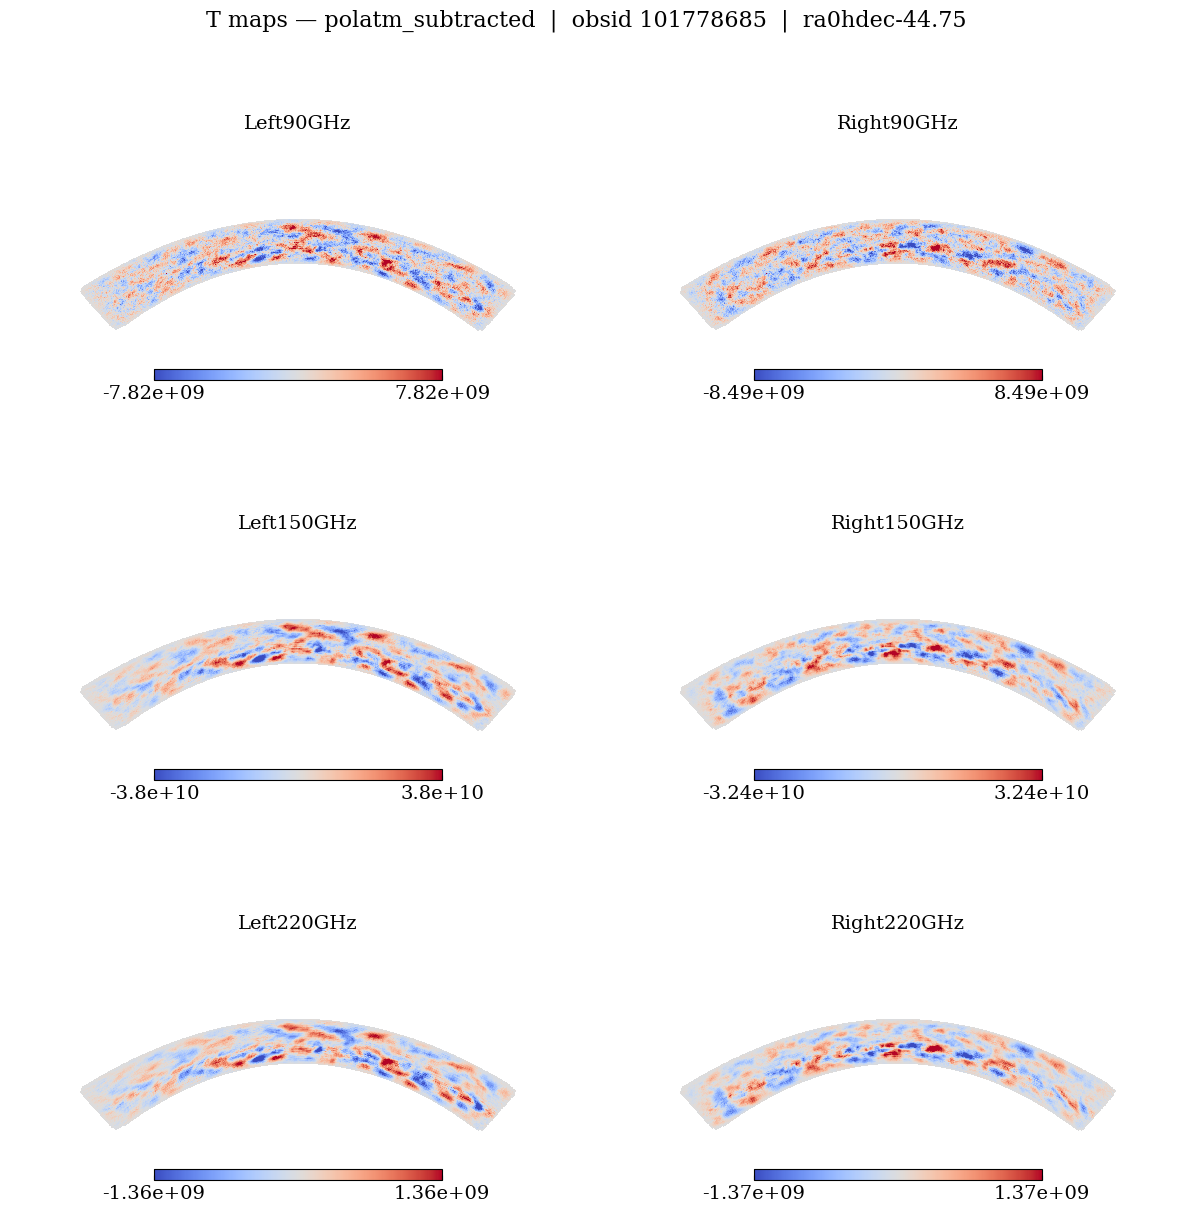

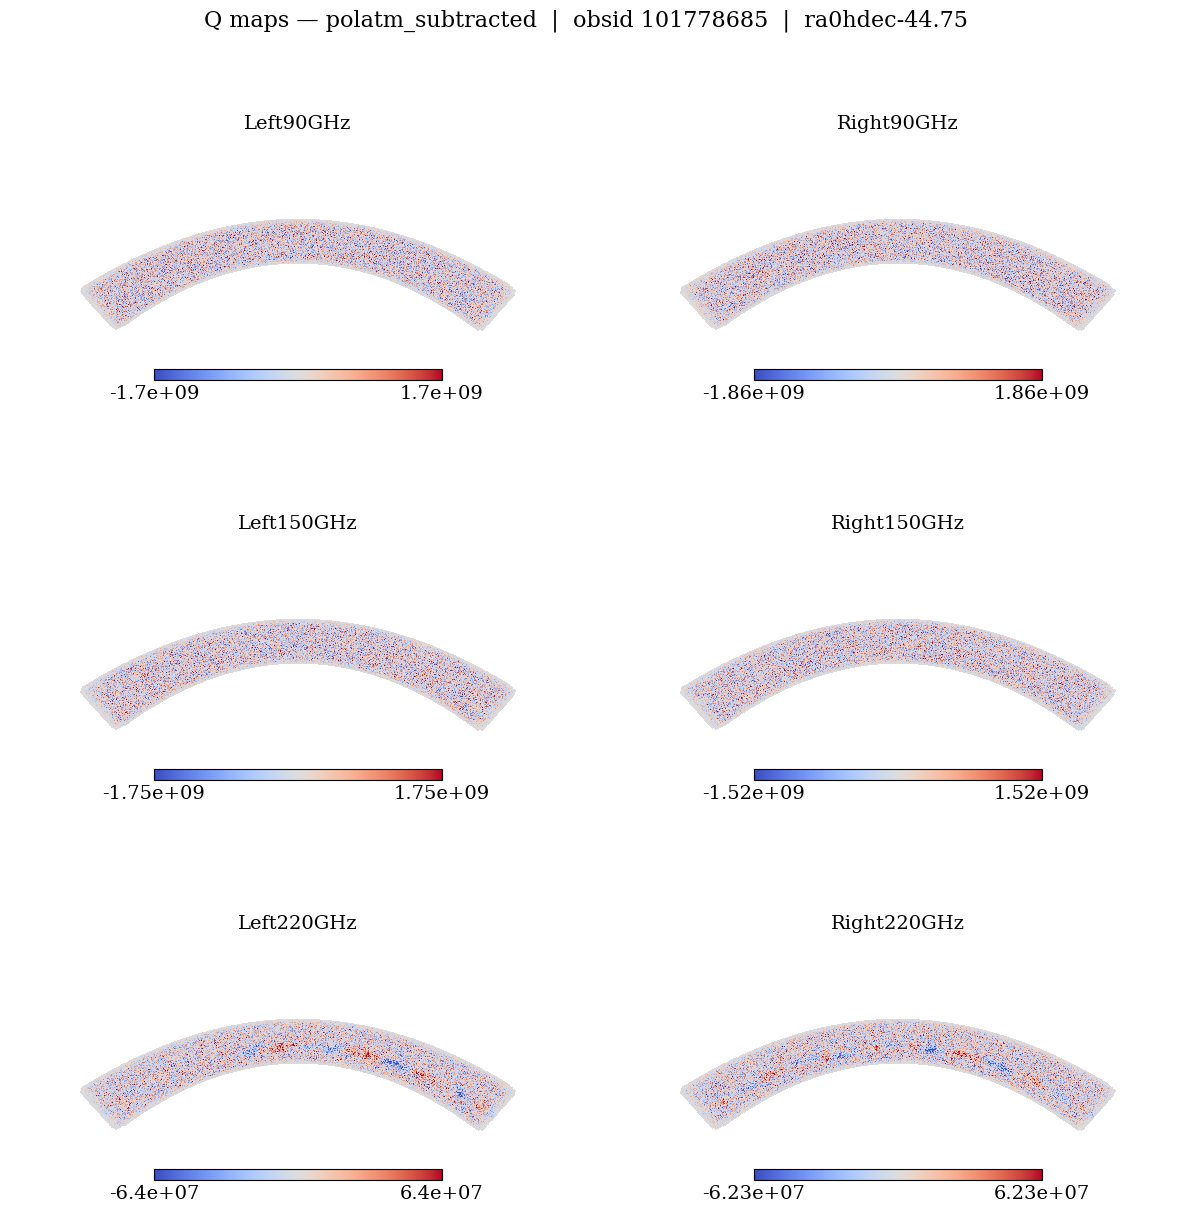

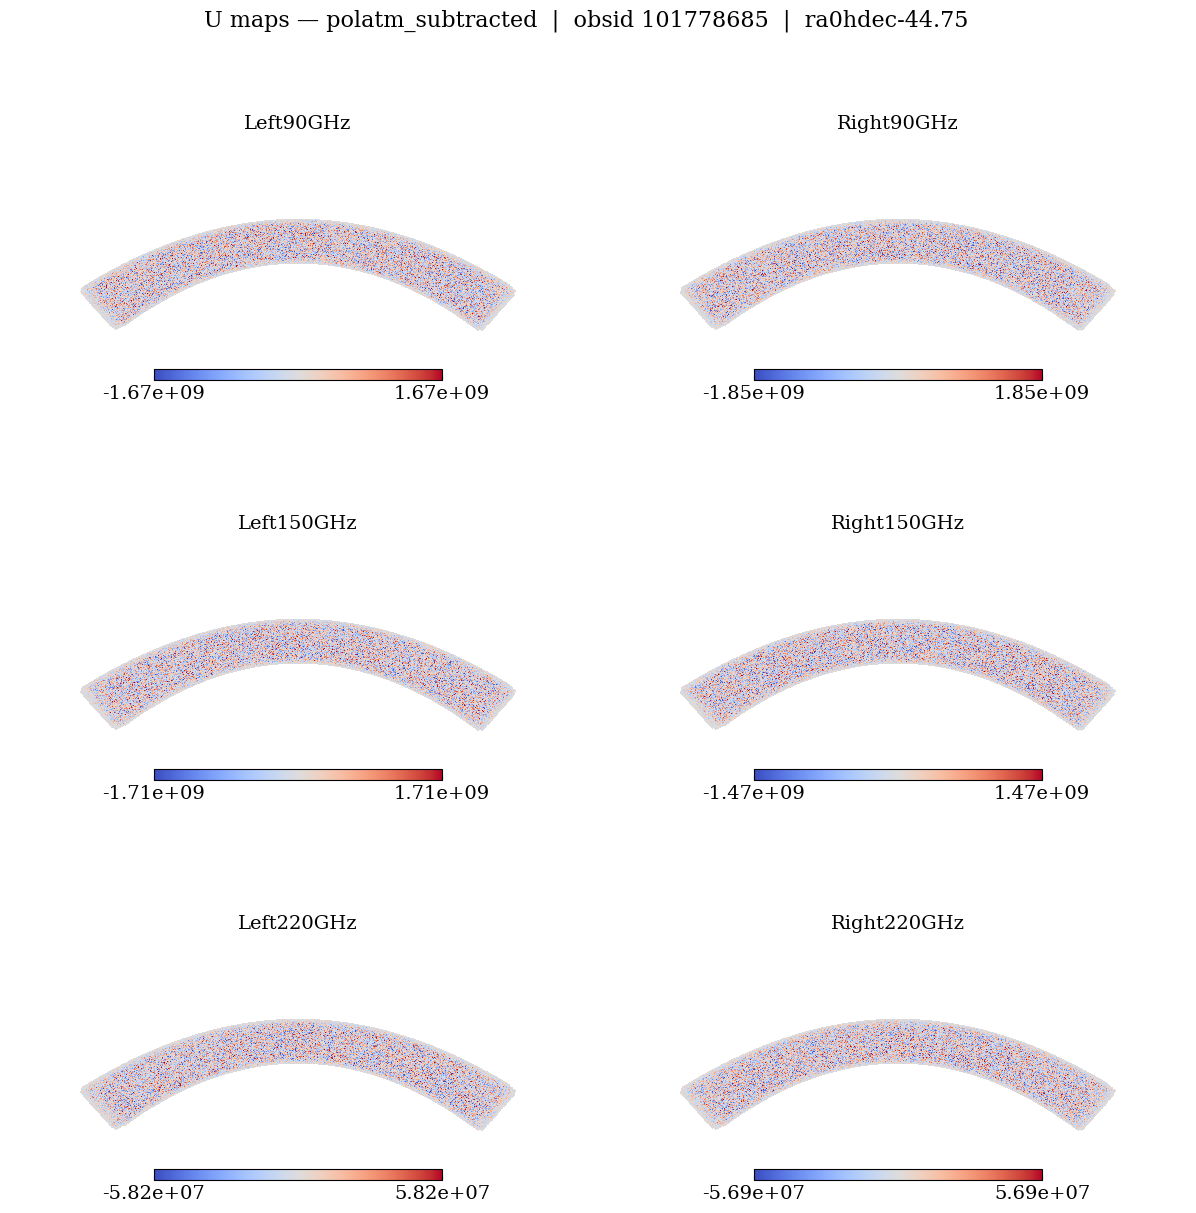

In [32]:
# --- 6.3  Plot T / Q / U (polatm-subtracted) ---
# rot_centre and layout are reused from §3.

plotter_polatm = MapPlotter(frames_polatm)

layout = [
    ("Left90GHz",  "Right90GHz"),
    ("Left150GHz", "Right150GHz"),
    ("Left220GHz", "Right220GHz"),
]

for stokes in ("T", "Q", "U"):
    fig = plotter_polatm.plot_grid(
        map_key=stokes,
        layout=layout,
        rot=rot_centre,
        suptitle=f"{stokes} maps — polatm_subtracted  |  obsid {polatm_obsid}  |  {subfield}",
    )
    plt.show()

In [ ]:
plot full coadd, one_thirtieth, multiply by point source masked apodisation mask , want subplot arcmin , unmasked 250 Jensky  -> see if htere are point sources if 100mijensky 

T and Q/U map -> find the few by few degrees (10by 10 patches) (2 pixels per acmin)
cartview 

[vwelke@scott ~]$ cd /sptlocal/
analysis/           .ipynb_checkpoints/ transfer/           user/               
[vwelke@scott ~]$ cd /sptlocal/user/creichardt/
[vwelke@scott creichardt]$ ls
bb2020                                                    HFI_celring_353_2048_Q.fits                   kmask_m150.npz
bk18_mask_largefield_cel_n0512.fits                       HFI_celring_353_2048_T.fits                   kmask_m200.npz
bk18_mask_largefield_gal_n0512.fits                       HFI_celring_353_2048_U.fits                   kmask_m250.npz
cls                                                       hfi_Q_217_2048_half1.fits                     lib
cluster_cosmo                                             hfi_Q_217_2048_half2.fits                     mll_dl_0p4medwt_6mJy150ghzv2_13000.npz
COM_Mask_Likelihood-polarization-143-hm1_2048_R3.00.fits  HFI_SkyMap_217_2048_R3.01_full.fits           mll_dl_0p4medwt_6mJy150ghzv2_13000.npz.npy
CosmoMC                                                   HFI_SkyMap_217_2048_R3.01_halfmission-1.fits  mll_dl_13000.npy
Healpix_3.80                                              HFI_SkyMap_217_2048_R3.01_halfmission-2.fits  mll_dl_13000.npz
Healpix_3.80.tar.gz                                       HFI_SkyMap_353_2048_R3.01_full.fits           mll_temp_3100.npz
healpy-data                                               HFI_SkyMap_353_2048_R3.01_halfmission-1.fits  NaMaster
HFI_353_Qbanded_bicep.fits                                HFI_SkyMap_353_2048_R3.01_halfmission-2.fits  out_maps
HFI_353_Qbanded.fits                                      hfi_T_217_2048_half1.fits                     pairwise_ksz
HFI_353_Ubanded_bicep.fits                                hfi_T_217_2048_half2.fits                     public_html
HFI_353_Ubanded.fits                                      hfi_U_217_2048_half1.fits                     summer_a_sources.npz
HFI_celring_217_2048_Q.fits                               hfi_U_217_2048_half2.fits                     summer_b_sources.npz
HFI_celring_217_2048_T.fits                               hiell_20192020                            summer_c_sources.npz
HFI_celring_217_2048_U.fits                               hiell2022                            xspec_2022
[vwelke@scott creichardt]$ cd bb2020


use  uremask8192_0p5medwt_100mJy_30arcmin.npz
   puremask8192_0p5medwt_250mJy_30arcmin.npz
  puremask8192_0p5medwt_250mJy_60arcmin.npz
    puremask8192_0p5medwt_250mJy_nodisk_30arcmin.npz
\   puremask8192_0p5medwt_250mJy_nodisk_60arcmin.npz
\   puremask8192_0p5medwt_30arcmin.npz
\   puremask8192_0p5medwt_60arcmin.npz

use healpy.cartview to iterate through the degrees and the full map 

apod_mask_path = "/sptlocal/user/creichardt/bb1920"

# load the few masks and store them in objects or whatsoever

# define the plotting function 



# This is relevant 

mock_in = os.path.join(
    simulated_maps_dir,
    "input_maps",
    "input_maps_realization421_220ghz.fits")
mock_out = os.path.join(
    simulated_maps_dir,
    "output_maps/masking_yes",
    "output_maps_masking_yes_realization421_220ghz.fits")

mock_in, mock_out = [
    healpy.read_map(mock, field=0, partial=True)
    for mock in [mock_in, mock_out]]

for mock, label in zip([mock_in, mock_out], ["input", "output"]):
    show_map_full_field(
        mock, -300, 300,
        r"220 GHz, mock observation {}, $\it{{T}}$ map".format(label),
        r"$\mathrm{{\mu}K}$",
        cmap="RdBu_r")
